# Dota 2 Friend Tracker — Exploration Notebook

Run top-to-bottom with an active internet connection. Responses are cached in `notebook_cache/` so re-runs don't hammer the API.

**Friends tracked:** Sherry · Haseeb · Abidi · Rafay · ABT

## 1 · Setup & Config

In [ ]:
import json, pickle, time, statistics
from pathlib import Path

import httpx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'figure.dpi':       120,
})
GOLD    = '#c89b3c'
GREEN   = '#3fb950'
RED     = '#f85149'
BLUE    = '#4d9de0'
PURPLE  = '#9b5de5'
ORANGE  = '#e0854d'
PINK    = '#e05d9b'
PALETTE = [GOLD, GREEN, RED, BLUE, PURPLE, ORANGE, PINK]  # 7 colours for 7 players
ROLE_NAMES = {1: 'Carry', 2: 'Mid', 3: 'Offlane', 4: 'Jungle', 5: 'Support'}

# ── Configurable parameters ───────────────────────────────────────────────────
# Number of matches to fetch and cache per player in §2b.
# Increase for richer history (costs API time on first run); decrease for faster setup.
# CLI equivalent: python cli.py refresh-matches --limit <N>
MATCH_LIMIT = 200

BASE_URL = 'https://api.opendota.com/api'
FRIENDS_FILE = Path('friends.json')
CACHE_DIR = Path('notebook_cache')
CACHE_DIR.mkdir(exist_ok=True)

with open(FRIENDS_FILE) as fh:
    FRIENDS = json.load(fh)['friends']

print('Friends loaded:')
for f in FRIENDS:
    print(f"  {f['label']:8s}  account_id={f['account_id']}")
print(f'\nMATCH_LIMIT = {MATCH_LIMIT}')

## 2 · Data Fetching

In [98]:
HEADERS = {'User-Agent': 'DotaTracker-Notebook/1.0'}

def _cache_key(path: str) -> str:
    return path.replace('/', '_').strip('_')

def api_get(path: str, force: bool = False):
    key = _cache_key(path)
    cache_file = CACHE_DIR / f"{key}.pkl"
    if cache_file.exists() and not force:
        with open(cache_file, 'rb') as fh:
            return pickle.load(fh)
    resp = httpx.get(f'{BASE_URL}{path}', headers=HEADERS, timeout=20)
    resp.raise_for_status()
    data = resp.json()
    with open(cache_file, 'wb') as fh:
        pickle.dump(data, fh)
    time.sleep(0.4)
    return data

def fetch_all(force: bool = False):
    result = {}
    for f in FRIENDS:
        aid = f['account_id']
        print(f"Fetching {f['label']}...", end=' ')
        profile = api_get(f'/players/{aid}', force)
        wl      = api_get(f'/players/{aid}/wl', force)
        recent  = api_get(f'/players/{aid}/recentMatches', force)
        heroes  = api_get(f'/players/{aid}/heroes', force)
        peers   = api_get(f'/players/{aid}/peers', force)
        totals  = api_get(f'/players/{aid}/totals', force)
        for m in recent:
            is_rad = m.get('player_slot', 0) < 128
            m['won'] = m['radiant_win'] if is_rad else not m['radiant_win']
            m['kda'] = round((m['kills'] + m['assists']) / max(m['deaths'], 1), 2)
            dur = max(m.get('duration', 1), 1)
            m['dmg_per_min']  = round(m.get('hero_damage', 0) / dur * 60, 1)
            m['lh_per_min']   = round(m.get('last_hits', 0)   / dur * 60, 2)
        result[aid] = {'label': f['label'], 'profile': profile, 'wl': wl,
                       'recent': recent, 'heroes': heroes, 'peers': peers, 'totals': totals}
        print('done')
    return result

hero_ref = api_get('/heroes')
HERO_NAMES = {h['id']: h['localized_name'] for h in hero_ref}

D = fetch_all()
print('\nAll data loaded.')

Fetching Sherry... done
Fetching Haseeb... done
Fetching Abidi... done
Fetching Rafay... done
Fetching ABT... done
Fetching Cancer... done
Fetching Zain... done

All data loaded.


## 2b · Deep Match Cache (200 matches per player)

Fetches the last 200 matches per player using two OpenDota endpoints:
1. `/players/{id}/matches?limit=200` → ordered match list (basic stats + match IDs)
2. `/matches/{match_id}` → full per-match stats (hero damage, wards, buybacks, etc.)

**Caching rules:**
- Per-player match lists are cached in `data/match_cache/player_match_ids/`
- Full match JSON is cached in `data/match_cache/matches/{match_id}.json`
- Match files are **permanent** — once saved they are never re-fetched
- Shared across players: if Haseeb & Abidi played together the match is fetched once

**First run:** ~600–900 API calls, ~5 min. Re-runs are instant.
**CLI equivalent:** `python cli.py refresh-matches [--limit 200] [--force]`

In [ ]:
MATCH_CACHE_DIR = Path('data/match_cache')
PLAYER_IDS_DIR  = MATCH_CACHE_DIR / 'player_match_ids'
MATCHES_DIR     = MATCH_CACHE_DIR / 'matches'
for _d in [MATCH_CACHE_DIR, PLAYER_IDS_DIR, MATCHES_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# MATCH_LIMIT is defined in §1 (Setup).  Change it there to fetch more/fewer matches.
# OpenDota free tier: 60 req/min. 1.05 s/call ~= 57 req/min -- safely under the cap.
_CALL_DELAY = 1.05

# ── Fetch helpers ─────────────────────────────────────────────────────────────

def _read_match_file(match_file: Path) -> str | None:
    """
    Read a cached match file, handling both UTF-8 and legacy cp1252 files.
    If the file was written without explicit encoding (Windows default cp1252),
    reads it as latin-1 (lossless for any byte) and rewrites it as UTF-8 in place.
    Returns None for empty files.
    """
    try:
        content = match_file.read_text(encoding='utf-8')
    except UnicodeDecodeError:
        # Legacy file written with Windows default encoding -- migrate to UTF-8
        content = match_file.read_text(encoding='latin-1')
        match_file.write_text(content, encoding='utf-8')
    return content if content.strip() else None

def _raw_get(url: str) -> dict | list:
    """Direct HTTP GET with rate-limit delay. UTF-8 aware. No pickle caching."""
    resp = httpx.get(url, headers=HEADERS, timeout=30)
    resp.raise_for_status()
    time.sleep(_CALL_DELAY)
    return resp.json()

def fetch_player_match_list(account_id: int, force: bool = False) -> list[dict]:
    """Fetch /players/{id}/matches?limit=MATCH_LIMIT. Cached per player as JSON."""
    cache_file = PLAYER_IDS_DIR / f'{account_id}.json'
    if cache_file.exists() and not force:
        return json.loads(cache_file.read_text(encoding='utf-8'))
    data = _raw_get(
        f'{BASE_URL}/players/{account_id}/matches?limit={MATCH_LIMIT}&significant=1'
    )
    cache_file.write_text(json.dumps(data), encoding='utf-8')
    return data

def fetch_full_match(match_id: int) -> dict | None:
    """
    Fetch /matches/{match_id}. Skips entirely if already cached.
    Returns None on error (private match, 404, rate-limit, empty response, etc.).
    Legacy cp1252 files are migrated to UTF-8 on first read (no re-fetch needed).
    Empty files are deleted and re-fetched.
    """
    match_file = MATCHES_DIR / f'{match_id}.json'
    if match_file.exists():
        content = _read_match_file(match_file)
        if content:
            return json.loads(content)
        match_file.unlink()  # empty file -- delete and re-fetch
    try:
        resp = httpx.get(f'{BASE_URL}/matches/{match_id}', headers=HEADERS, timeout=30)
        resp.raise_for_status()
        text = resp.text
        if not text.strip():
            return None  # empty body (silent rate-limit or private match)
        match_file.write_text(text, encoding='utf-8')
        time.sleep(_CALL_DELAY)
        return resp.json()
    except Exception as exc:
        print(f'  [warn] {match_id}: {exc}')
        return None

def extract_player_stats(match: dict, account_id: int) -> dict | None:
    """Extract one player's flat stats row from a full match dict."""
    for p in match.get('players', []):
        if p.get('account_id') != account_id:
            continue
        is_rad = p.get('player_slot', 0) < 128
        won    = match.get('radiant_win', False) if is_rad else not match.get('radiant_win', False)
        dur    = max(match.get('duration', 1), 1)
        k, d, a = p.get('kills', 0), p.get('deaths', 0), p.get('assists', 0)
        return {
            'match_id':        match['match_id'],
            'hero_id':         p.get('hero_id'),
            'kills':           k,
            'deaths':          d,
            'assists':         a,
            'gold_per_min':    p.get('gold_per_min', 0),
            'xp_per_min':      p.get('xp_per_min', 0),
            'last_hits':       p.get('last_hits', 0),
            'denies':          p.get('denies', 0),
            'hero_damage':     p.get('hero_damage', 0),
            'tower_damage':    p.get('tower_damage', 0),
            'hero_healing':    p.get('hero_healing', 0),
            'obs_placed':      p.get('obs_placed', 0),
            'sen_placed':      p.get('sen_placed', 0),
            'buyback_count':   p.get('buyback_count', 0),
            'net_worth':       p.get('net_worth', 0),
            'actions_per_min': p.get('actions_per_min', 0),
            'lane_role':       p.get('lane_role'),
            'is_roaming':      p.get('is_roaming', False),
            'duration':        dur,
            'won':             won,
            'kda':             round((k + a) / max(d, 1), 2),
            'dmg_per_min':     round(p.get('hero_damage', 0) / dur * 60, 1),
            'lh_per_min':      round(p.get('last_hits', 0)  / dur * 60, 2),
        }
    return None

# ── Step 1: Fetch per-player match ID lists ───────────────────────────────────
print(f'Fetching last {MATCH_LIMIT} match IDs per player...')
MATCH_LISTS = {}
for f in FRIENDS:
    aid    = f['account_id']
    cached = (PLAYER_IDS_DIR / f'{aid}.json').exists()
    print(f"  {f['label']:8s}", end='  ')
    ml = fetch_player_match_list(aid)
    MATCH_LISTS[aid] = ml
    print(f'{len(ml)} matches  {"(cached)" if cached else "(fetched)"}')

# ── Step 2: Identify uncached / empty match files ─────────────────────────────
all_ids = {m['match_id'] for ml in MATCH_LISTS.values() for m in ml}
cached_ids = {
    int(f.stem) for f in MATCHES_DIR.iterdir()
    if f.suffix == '.json' and f.stat().st_size > 0
}
to_fetch = sorted(all_ids - cached_ids)

print(f'\n{len(all_ids)} unique matches across all players')
print(f'{len(cached_ids & all_ids)} already cached, {len(to_fetch)} to fetch '
      f'(~{len(to_fetch) * _CALL_DELAY / 60:.0f} min at {60/_CALL_DELAY:.0f} req/min)')

# ── Step 3: Fetch uncached full matches ───────────────────────────────────────
if to_fetch:
    errors = 0
    for i, mid in enumerate(to_fetch):
        if i % 50 == 0:
            pct = i / len(to_fetch) * 100
            print(f'  [{i:4d}/{len(to_fetch)}]  {pct:.0f}%  errors={errors}', flush=True)
        if fetch_full_match(mid) is None:
            errors += 1
    print(f'\nFetch complete -- {len(to_fetch) - errors} ok, {errors} errors.')

total = len(list(MATCHES_DIR.iterdir()))
print(f'Cache total: {total} match files')

# ── Step 4: Build DEEP dict -- per-player list of MATCH_LIMIT-match stat rows ─
print(f'\nBuilding DEEP match history ({MATCH_LIMIT} matches per player)...')
DEEP: dict[int, list[dict]] = {}
for f in FRIENDS:
    aid   = f['account_id']
    rows  = []
    for m_basic in MATCH_LISTS.get(aid, []):
        m_full = fetch_full_match(m_basic['match_id'])  # instant from cache
        if m_full is None:
            continue
        row = extract_player_stats(m_full, aid)
        if row:
            rows.append(row)
    DEEP[aid] = rows
    wr = sum(1 for r in rows if r['won']) / len(rows) * 100 if rows else 0
    print(f"  {f['label']:8s}  {len(rows)} matches  {wr:.1f}% WR")

print('\nDEEP ready -- use get_matches(account_id) for full-history analysis.')

def get_matches(aid: int) -> list[dict]:
    """Return DEEP cache for a player. Falls back to recentMatches if §2b not yet run."""
    return DEEP.get(aid, D[aid]['recent'])

## 3 · Winrate Overview

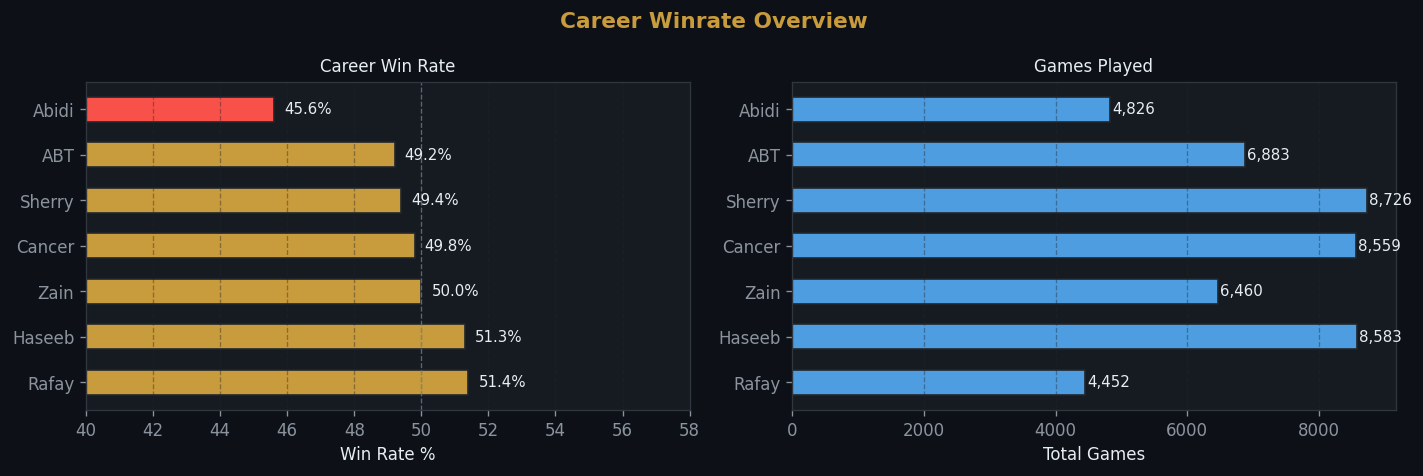

 Label  Wins  Losses  Total  WR%     Rank
 Rafay  2288    2164   4452 51.4  Ancient
Haseeb  4404    4179   8583 51.3   Divine
  Zain  3231    3229   6460 50.0   Archon
Cancer  4262    4297   8559 49.8   Legend
Sherry  4308    4418   8726 49.4   Archon
   ABT  3386    3497   6883 49.2   Archon
 Abidi  2199    2627   4826 45.6 Guardian


In [100]:
rows = []
for aid, d in D.items():
    wins   = d['wl']['win']
    losses = d['wl']['lose']
    total  = wins + losses
    wr     = round(wins / total * 100, 1) if total else 0
    rt     = d['profile'].get('rank_tier')
    medal  = {1:'Herald',2:'Guardian',3:'Crusader',4:'Archon',5:'Legend',6:'Ancient',7:'Divine',8:'Immortal'}.get(rt//10 if rt else 0, 'Unranked')
    rows.append({'Label': d['label'], 'Wins': wins, 'Losses': losses, 'Total': total, 'WR%': wr, 'Rank': medal})

df_wl = pd.DataFrame(rows).sort_values('WR%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Career Winrate Overview', color=GOLD, fontsize=13, fontweight='bold')

ax = axes[0]
colors = [GREEN if w >= 52 else GOLD if w >= 48 else RED for w in df_wl['WR%']]
bars = ax.barh(df_wl['Label'], df_wl['WR%'], color=colors, edgecolor='#21262d', height=0.55)
ax.axvline(50, color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, df_wl['WR%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
ax.set_xlim(40, 58); ax.set_xlabel('Win Rate %'); ax.set_title('Career Win Rate', fontsize=10); ax.grid(axis='x', alpha=0.4)

ax2 = axes[1]
ax2.barh(df_wl['Label'], df_wl['Total'], color=BLUE, edgecolor='#21262d', height=0.55)
for bar, val in zip(ax2.patches, df_wl['Total']):
    ax2.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax2.set_xlabel('Total Games'); ax2.set_title('Games Played', fontsize=10); ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('notebook_cache/winrate_overview.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(df_wl[['Label','Wins','Losses','Total','WR%','Rank']].to_string(index=False))

## 4 · KDA Trend (200 matches — rolling average)

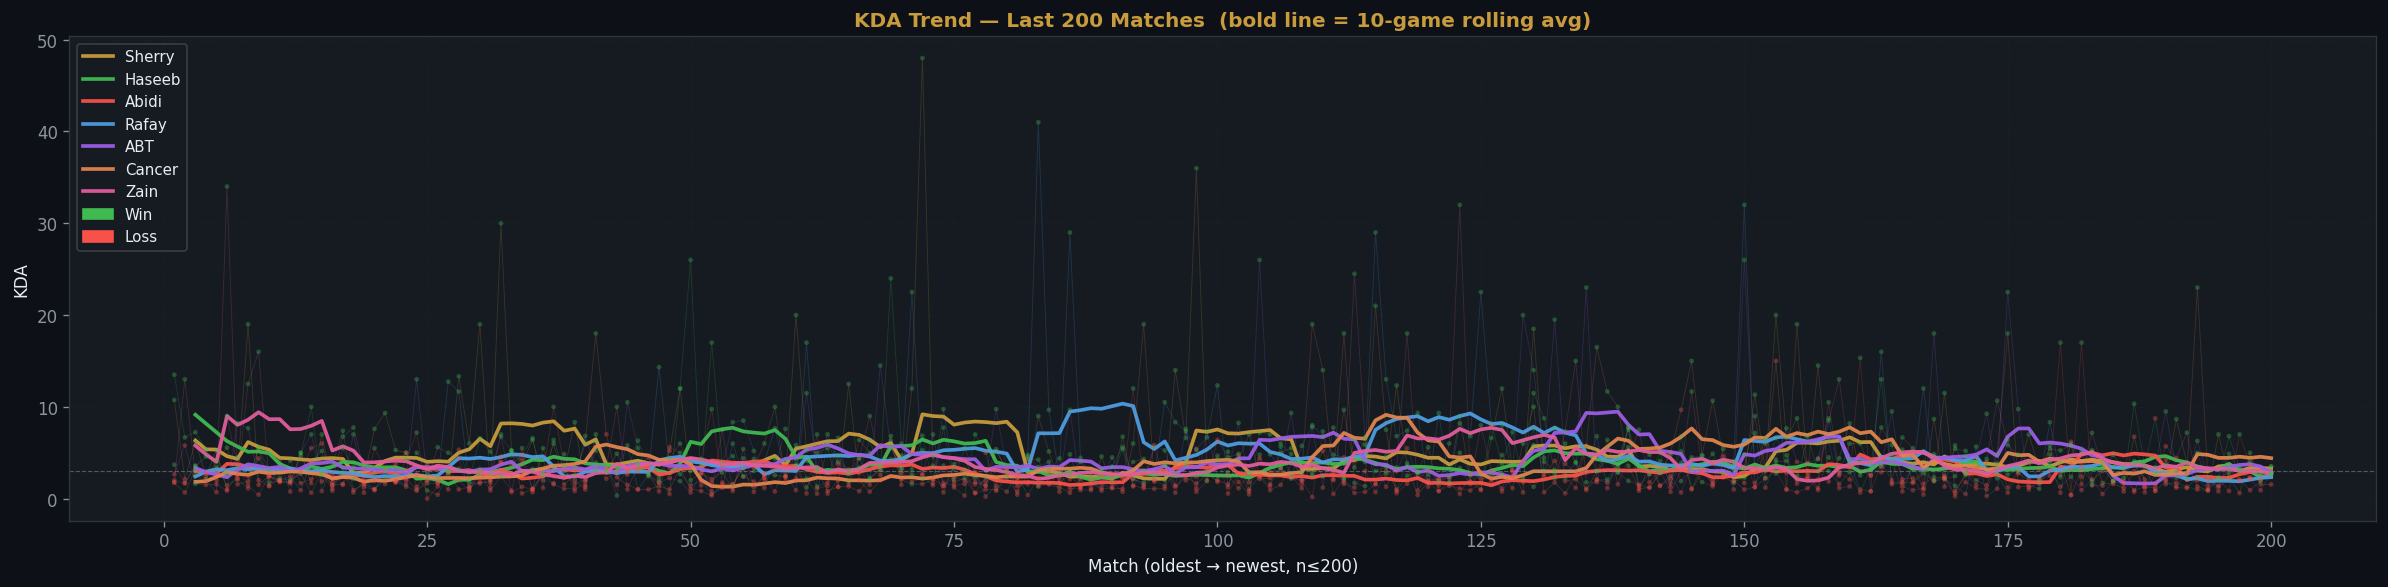

In [101]:
fig, ax = plt.subplots(figsize=(20, 5))
fig.patch.set_facecolor('#0d1117')

for (aid, d), color in zip(D.items(), PALETTE):
    matches = list(reversed(get_matches(aid)))
    kdas    = [m['kda'] for m in matches]
    x       = list(range(1, len(kdas) + 1))
    # Raw dots coloured by win/loss
    ax.scatter(x, kdas, color=[GREEN if m['won'] else RED for m in matches],
               s=8, zorder=4, edgecolors='none', alpha=0.35)
    # Thin raw line
    ax.plot(x, kdas, color=color, linewidth=0.5, alpha=0.2)
    # Bold 10-game rolling average
    roll = pd.Series(kdas).rolling(10, min_periods=3).mean()
    ax.plot(x, roll, color=color, linewidth=2.2, label=d['label'], alpha=0.95)

ax.axhline(3.0, color='#8b949e', linestyle='--', linewidth=0.7, alpha=0.5)
n_shown = max(len(get_matches(aid)) for aid in D)
ax.set_xlabel(f'Match (oldest → newest, n≤{n_shown})')
ax.set_ylabel('KDA')
ax.set_title('KDA Trend — Last 200 Matches  (bold line = 10-game rolling avg)',
             color=GOLD, fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
win_patch  = mpatches.Patch(color=GREEN, label='Win')
loss_patch = mpatches.Patch(color=RED,   label='Loss')
ax.legend(handles=ax.get_legend_handles_labels()[0] + [win_patch, loss_patch],
          labels =ax.get_legend_handles_labels()[1] + ['Win', 'Loss'],
          loc='upper left', framealpha=0.2, fontsize=9)
plt.tight_layout()
plt.savefig('notebook_cache/kda_trend.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5 · Hero Heatmap (top 10 heroes × friends, colour = winrate)

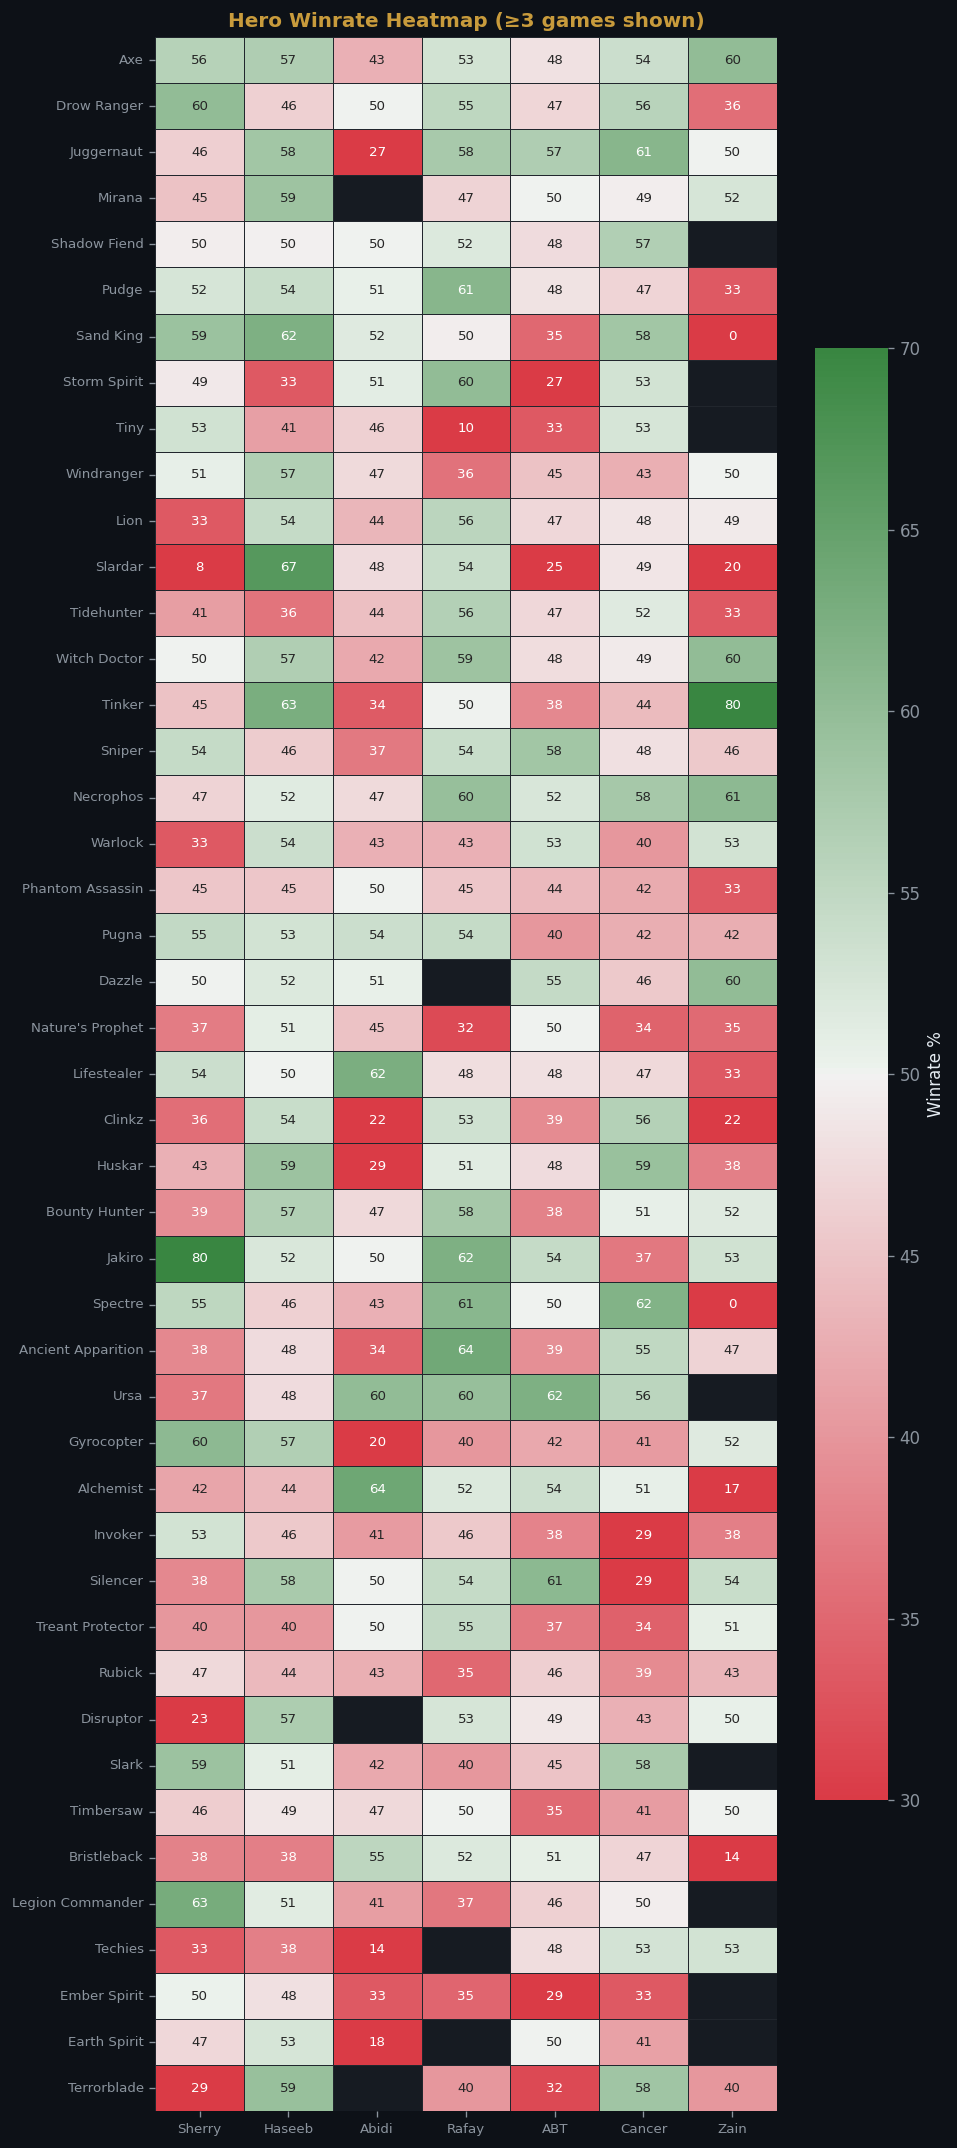

In [102]:
all_top = set()
for d in D.values():
    top = sorted(d['heroes'], key=lambda h: h['games'], reverse=True)[:10]
    all_top.update(h['hero_id'] for h in top)

top_heroes = sorted(all_top)
labels_f = [d['label'] for d in D.values()]
labels_h = [HERO_NAMES.get(hid, f'Hero {hid}') for hid in top_heroes]

matrix = np.full((len(top_heroes), len(labels_f)), np.nan)
for col_i, (aid, d) in enumerate(D.items()):
    hero_map = {h['hero_id']: h for h in d['heroes']}
    for row_i, hid in enumerate(top_heroes):
        h = hero_map.get(hid)
        if h and h['games'] >= 3:
            matrix[row_i, col_i] = round(h['win'] / h['games'] * 100, 1)

df_heat = pd.DataFrame(matrix, index=labels_h, columns=labels_f)

fig, ax = plt.subplots(figsize=(8, max(6, len(top_heroes) * 0.4)))
fig.patch.set_facecolor('#0d1117')
cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(df_heat, ax=ax, cmap=cmap, center=50, vmin=30, vmax=70,
            annot=True, fmt='.0f', linewidths=0.4, linecolor='#21262d',
            cbar_kws={'label': 'Winrate %', 'shrink': 0.7}, annot_kws={'size': 8})
ax.set_title('Hero Winrate Heatmap (≥3 games shown)', color=GOLD, fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.savefig('notebook_cache/hero_heatmap.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6 · GPM / XPM Scatter (coloured by win/loss)

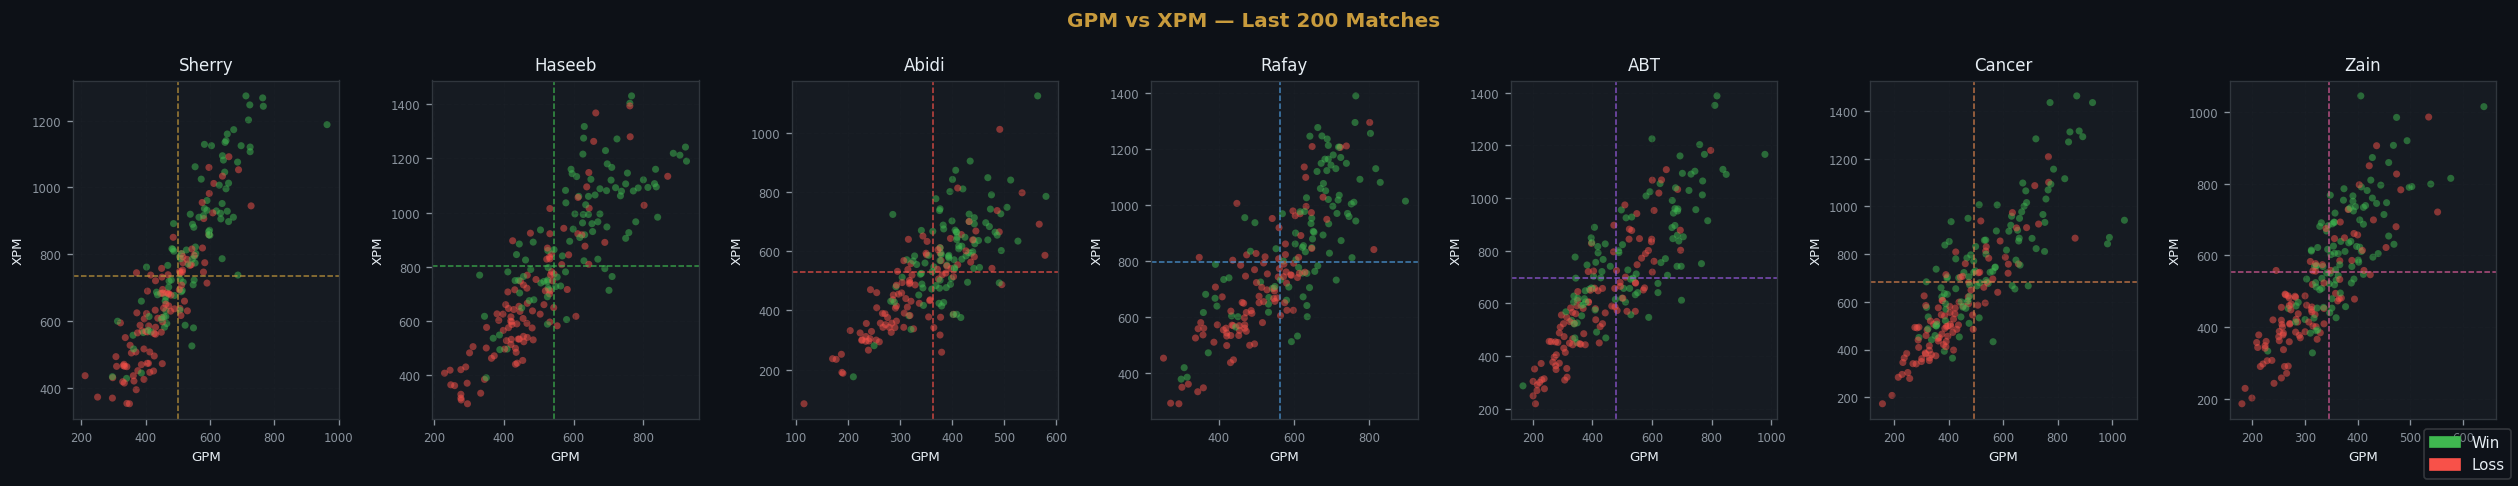

In [103]:
fig, axes = plt.subplots(1, len(D), figsize=(len(D) * 3, 4), sharey=False)
fig.suptitle('GPM vs XPM — Last 200 Matches', color=GOLD, fontsize=12, fontweight='bold')

for ax, (aid, d), col in zip(axes, D.items(), PALETTE):
    matches = get_matches(aid)
    gpms = [m['gold_per_min'] for m in matches]
    xpms = [m['xp_per_min']   for m in matches]
    colors = [GREEN if m['won'] else RED for m in matches]
    ax.scatter(gpms, xpms, c=colors, s=18, alpha=0.5, edgecolors='none')
    ax.axvline(np.mean(gpms), color=col, linewidth=0.9, linestyle='--', alpha=0.8)
    ax.axhline(np.mean(xpms), color=col, linewidth=0.9, linestyle='--', alpha=0.8)
    ax.set_title(d['label'], fontsize=10); ax.set_xlabel('GPM', fontsize=8); ax.set_ylabel('XPM', fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.25)

fig.legend(handles=[mpatches.Patch(color=GREEN, label='Win'), mpatches.Patch(color=RED, label='Loss')],
           loc='lower right', framealpha=0.2, fontsize=9)
plt.tight_layout()
plt.savefig('notebook_cache/gpm_xpm_scatter.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 7 · Recent Form (sparkline-style W/L sequence)

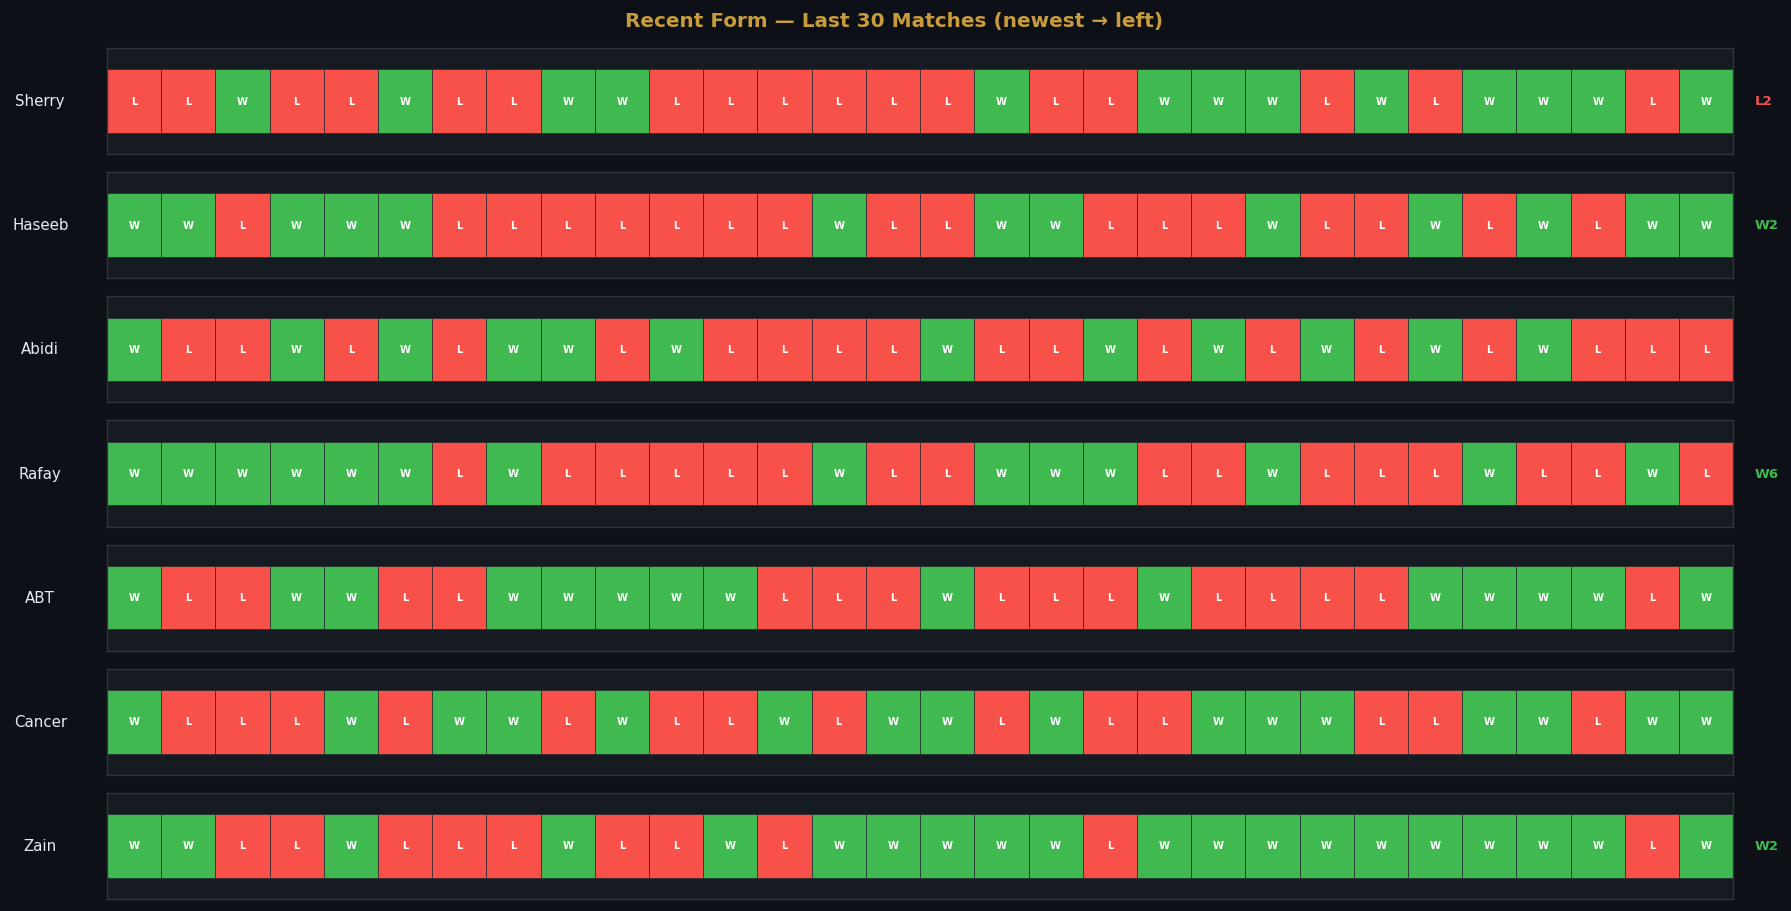

In [104]:
FORM_WINDOW = 30  # matches shown per player (newest first)
n_players   = len(D)
fig, axes   = plt.subplots(n_players, 1, figsize=(15, n_players * 1.1))
fig.suptitle(f'Recent Form — Last {FORM_WINDOW} Matches (newest → left)',
             color=GOLD, fontsize=12, fontweight='bold')
if n_players == 1:
    axes = [axes]

for ax, (aid, d) in zip(axes, D.items()):
    matches = get_matches(aid)[:FORM_WINDOW]
    for i, m in enumerate(matches):
        col = GREEN if m['won'] else RED
        ax.barh(0, 1, left=i, height=0.6, color=col, edgecolor='#21262d', linewidth=0.4)
        ax.text(i + 0.5, 0, 'W' if m['won'] else 'L',
                ha='center', va='center', fontsize=6, color='white', fontweight='bold')
    ax.set_xlim(0, FORM_WINDOW); ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([]); ax.set_xticks([])
    ax.set_ylabel(d['label'], rotation=0, labelpad=40, va='center', fontsize=9)
    streak, first_won = 0, matches[0]['won'] if matches else None
    for m in matches:
        if m['won'] == first_won:
            streak += 1
        else:
            break
    if streak >= 2:
        ax.text(FORM_WINDOW + 0.4, 0, f"{'W' if first_won else 'L'}{streak}",
                va='center', fontsize=8, color=GREEN if first_won else RED, fontweight='bold')

plt.tight_layout()
plt.savefig('notebook_cache/recent_form.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 8 · Group Synergy Matrix

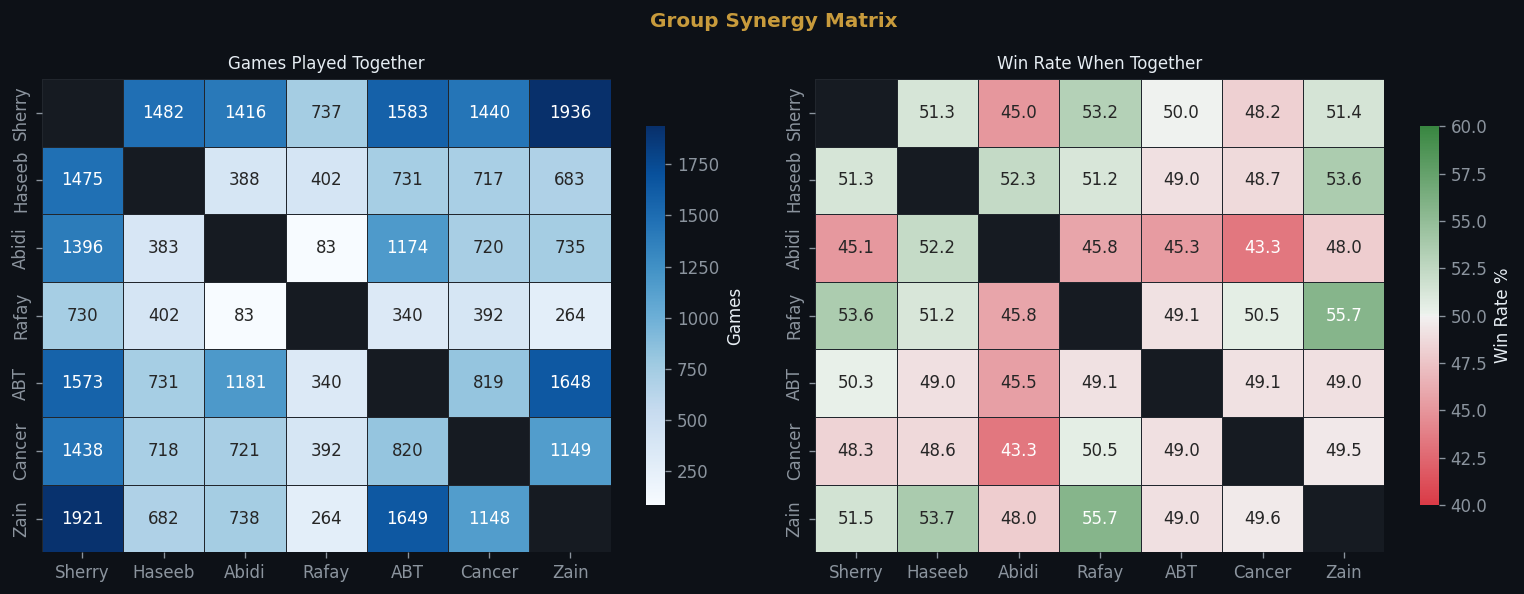


Games Together:
        Sherry  Haseeb   Abidi  Rafay     ABT  Cancer    Zain
Sherry     NaN  1482.0  1416.0  737.0  1583.0  1440.0  1936.0
Haseeb  1475.0     NaN   388.0  402.0   731.0   717.0   683.0
Abidi   1396.0   383.0     NaN   83.0  1174.0   720.0   735.0
Rafay    730.0   402.0    83.0    NaN   340.0   392.0   264.0
ABT     1573.0   731.0  1181.0  340.0     NaN   819.0  1648.0
Cancer  1438.0   718.0   721.0  392.0   820.0     NaN  1149.0
Zain    1921.0   682.0   738.0  264.0  1649.0  1148.0     NaN

Win Rate Together (%):
        Sherry  Haseeb  Abidi  Rafay   ABT  Cancer  Zain
Sherry     NaN    51.3   45.0   53.2  50.0    48.2  51.4
Haseeb    51.3     NaN   52.3   51.2  49.0    48.7  53.6
Abidi     45.1    52.2    NaN   45.8  45.3    43.3  48.0
Rafay     53.6    51.2   45.8    NaN  49.1    50.5  55.7
ABT       50.3    49.0   45.5   49.1   NaN    49.1  49.0
Cancer    48.3    48.6   43.3   50.5  49.0     NaN  49.5
Zain      51.5    53.7   48.0   55.7  49.0    49.6   NaN


In [105]:
friend_ids   = [f['account_id'] for f in FRIENDS]
friend_names = [f['label']       for f in FRIENDS]
n = len(friend_ids)
games_mat = np.zeros((n, n))
wr_mat    = np.full((n, n), np.nan)

for i, aid in enumerate(friend_ids):
    peer_map = {p['account_id']: p for p in D[aid]['peers']}
    for j, other_id in enumerate(friend_ids):
        if i == j: continue
        p = peer_map.get(other_id)
        if p and p.get('with_games', 0) > 0:
            g, w = p['with_games'], p['with_win']
            games_mat[i, j] = g
            wr_mat[i, j]    = round(w / g * 100, 1)

# Fill diagonal on the numpy arrays BEFORE creating DataFrames.
# pandas 2.x returns a read-only view from .values, so np.fill_diagonal
# on df.values raises ValueError: underlying array is read-only.
np.fill_diagonal(games_mat, np.nan)
# wr_mat diagonal is already NaN (initialized with np.full(..., np.nan))

df_games = pd.DataFrame(games_mat, index=friend_names, columns=friend_names)
df_wr    = pd.DataFrame(wr_mat,    index=friend_names, columns=friend_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Group Synergy Matrix', color=GOLD, fontsize=12, fontweight='bold')

sns.heatmap(df_games, ax=axes[0], cmap='Blues', annot=True, fmt='.0f',
            linewidths=0.4, linecolor='#21262d',
            cbar_kws={'label': 'Games', 'shrink': 0.8}, annot_kws={'size': 10})
axes[0].set_title('Games Played Together', fontsize=10)

sns.heatmap(df_wr, ax=axes[1], cmap=sns.diverging_palette(10, 130, as_cmap=True),
            center=50, vmin=40, vmax=60,
            annot=True, fmt='.1f', linewidths=0.4, linecolor='#21262d',
            cbar_kws={'label': 'Win Rate %', 'shrink': 0.8}, annot_kws={'size': 10})
axes[1].set_title('Win Rate When Together', fontsize=10)

for ax_ in axes: ax_.set_xlabel(''); ax_.set_ylabel('')
plt.tight_layout()
plt.savefig('notebook_cache/group_synergy.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\nGames Together:'); print(df_games.to_string())
print('\nWin Rate Together (%):'); print(df_wr.to_string())

## 9 · Pipeline Diagram

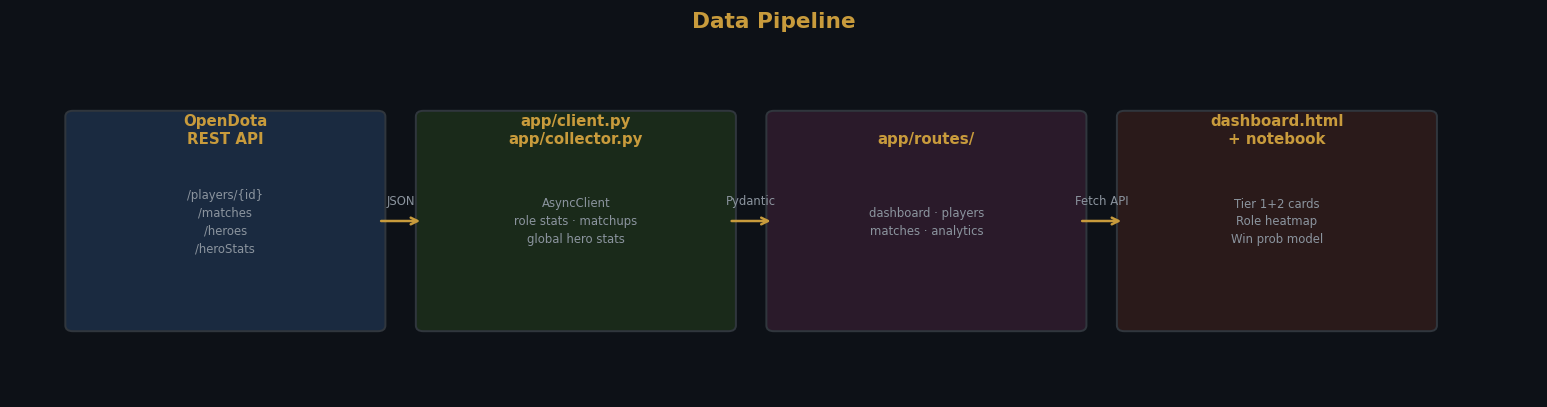

In [106]:
fig, ax = plt.subplots(figsize=(13, 3.5))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#0d1117')
ax.set_xlim(0, 10); ax.set_ylim(0, 3); ax.axis('off')
ax.set_title('Data Pipeline', color=GOLD, fontsize=13, fontweight='bold', pad=12)

boxes = [
    (0.4, 'OpenDota\nREST API',   '/players/{id}\n/matches\n/heroes\n/heroStats', '#1a2a40'),
    (2.7, 'app/client.py\napp/collector.py', 'AsyncClient\nrole stats · matchups\nglobal hero stats', '#1a2a1a'),
    (5.0, 'app/routes/',          'dashboard · players\nmatches · analytics', '#2a1a2a'),
    (7.3, 'dashboard.html\n+ notebook', 'Tier 1+2 cards\nRole heatmap\nWin prob model', '#2a1a1a'),
]

for x, title, body, bg in boxes:
    rect = mpatches.FancyBboxPatch((x, 0.6), 2.0, 1.8, boxstyle='round,pad=0.05', facecolor=bg, edgecolor='#30363d', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x+1.0, 2.15, title, ha='center', va='bottom', fontsize=9, fontweight='bold', color=GOLD)
    ax.text(x+1.0, 1.5,  body,  ha='center', va='center', fontsize=7, color='#8b949e', linespacing=1.5)

for x_start in [2.4, 4.7, 7.0]:
    ax.annotate('', xy=(x_start+0.3, 1.5), xytext=(x_start, 1.5),
                arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))

ax.text(2.55, 1.65, 'JSON',     fontsize=7, color='#8b949e', ha='center')
ax.text(4.85, 1.65, 'Pydantic', fontsize=7, color='#8b949e', ha='center')
ax.text(7.15, 1.65, 'Fetch API',fontsize=7, color='#8b949e', ha='center')

plt.tight_layout()
plt.savefig('notebook_cache/pipeline_diagram.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Tier 2 Stats
Sections 10–12 use data already loaded in Section 2 — no extra API calls needed.

## 10 · Damage & Last Hits per Minute

Impact metrics averaged over up to 200 matches per player:
 Label  DMG/min  LH/min  Twr DMG   n
 Rafay    890.6    5.85   4717.0 200
Haseeb    824.6    5.56   4405.0 200
Cancer    715.6    4.41   2790.0 200
Sherry    686.0    5.26   2706.0 200
   ABT    609.7    4.87   4342.0 200
  Zain    423.0    1.98   1814.0 200
 Abidi    399.0    2.60    564.0 200


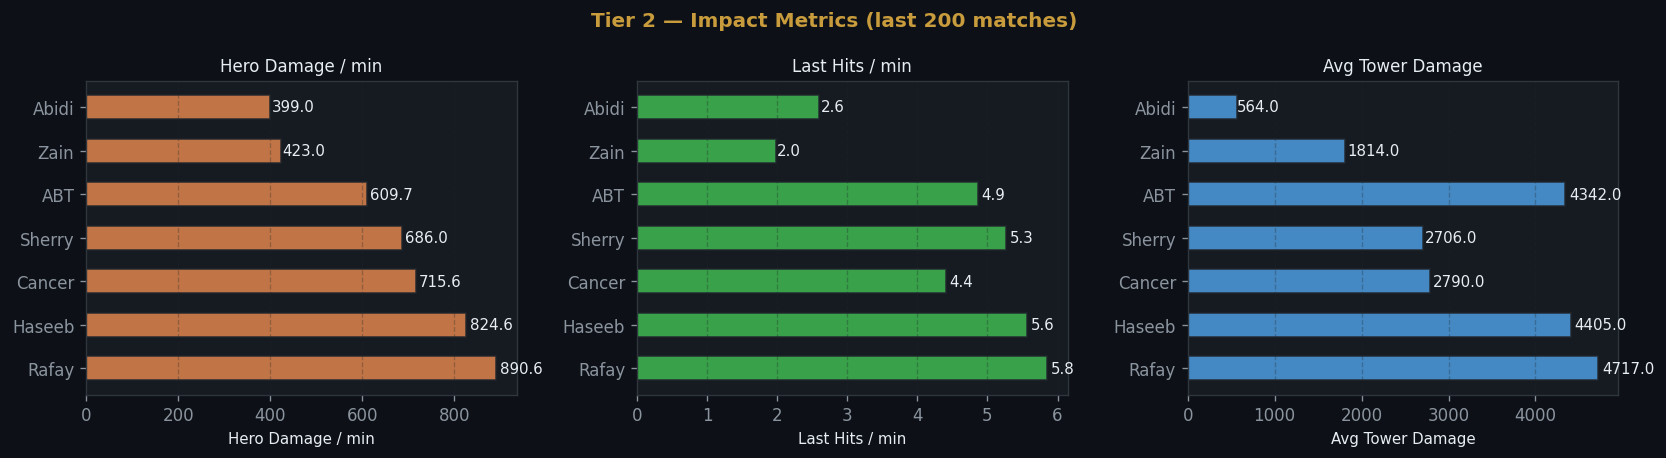

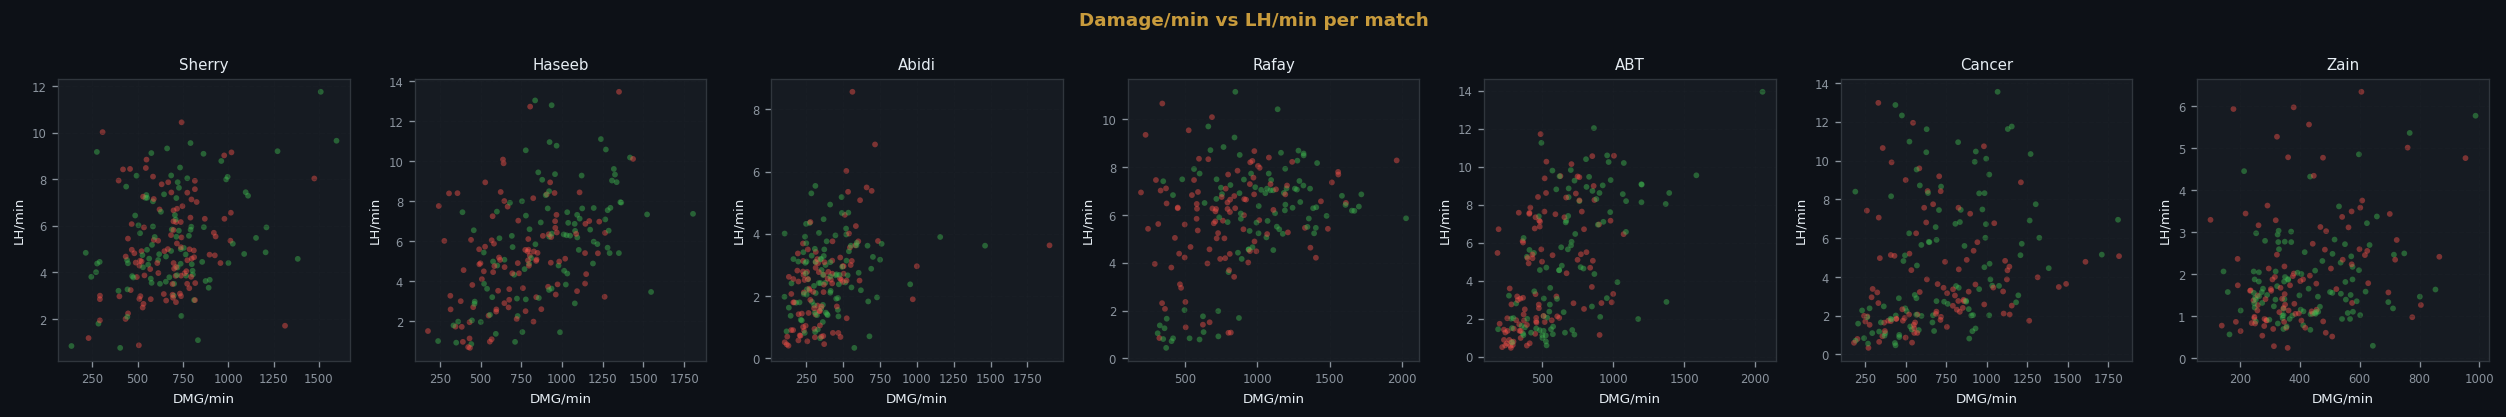

In [107]:
# Build per-player summary of Tier 2 impact metrics using full 200-match history
t2_rows = []
for aid, d in D.items():
    ms = get_matches(aid)
    n  = len(ms)
    if n == 0:
        continue
    t2_rows.append({
        'Label':   d['label'],
        'DMG/min': round(sum(m['dmg_per_min'] for m in ms) / n, 1),
        'LH/min':  round(sum(m['lh_per_min']  for m in ms) / n, 2),
        'Twr DMG': round(sum(m.get('tower_damage', 0) for m in ms) / n, 0),
        'n':       n,
    })

df_t2 = pd.DataFrame(t2_rows).sort_values('DMG/min', ascending=False)
print(f'Impact metrics averaged over up to {MATCH_LIMIT} matches per player:')
print(df_t2.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, max(3, len(df_t2) * 0.55)))
fig.suptitle(f'Tier 2 — Impact Metrics (last {MATCH_LIMIT} matches)',
             color=GOLD, fontsize=12, fontweight='bold')

for ax, col, color, label in [
    (axes[0], 'DMG/min', ORANGE, 'Hero Damage / min'),
    (axes[1], 'LH/min',  GREEN,  'Last Hits / min'),
    (axes[2], 'Twr DMG', BLUE,   'Avg Tower Damage'),
]:
    bars = ax.barh(df_t2['Label'], df_t2[col], color=color,
                   edgecolor='#21262d', height=0.55, alpha=0.85)
    for bar, val in zip(bars, df_t2[col]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=9)
    ax.set_xlabel(label, fontsize=9); ax.set_title(label, fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('notebook_cache/t2_impact_metrics.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Scatter: DMG/min vs LH/min per match, coloured by win/loss
fig, axes = plt.subplots(1, len(D), figsize=(len(D) * 3, 3.5), sharey=False)
fig.suptitle('Damage/min vs LH/min per match', color=GOLD, fontsize=11, fontweight='bold')

for ax, (aid, d), col in zip(axes, D.items(), PALETTE):
    ms = get_matches(aid)
    ax.scatter([m['dmg_per_min'] for m in ms], [m['lh_per_min'] for m in ms],
               c=[GREEN if m['won'] else RED for m in ms], s=12, alpha=0.45, edgecolors='none')
    ax.set_title(d['label'], fontsize=9)
    ax.set_xlabel('DMG/min', fontsize=8); ax.set_ylabel('LH/min', fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('notebook_cache/t2_dmg_lh_scatter.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 11 · Role Performance (200 matches)

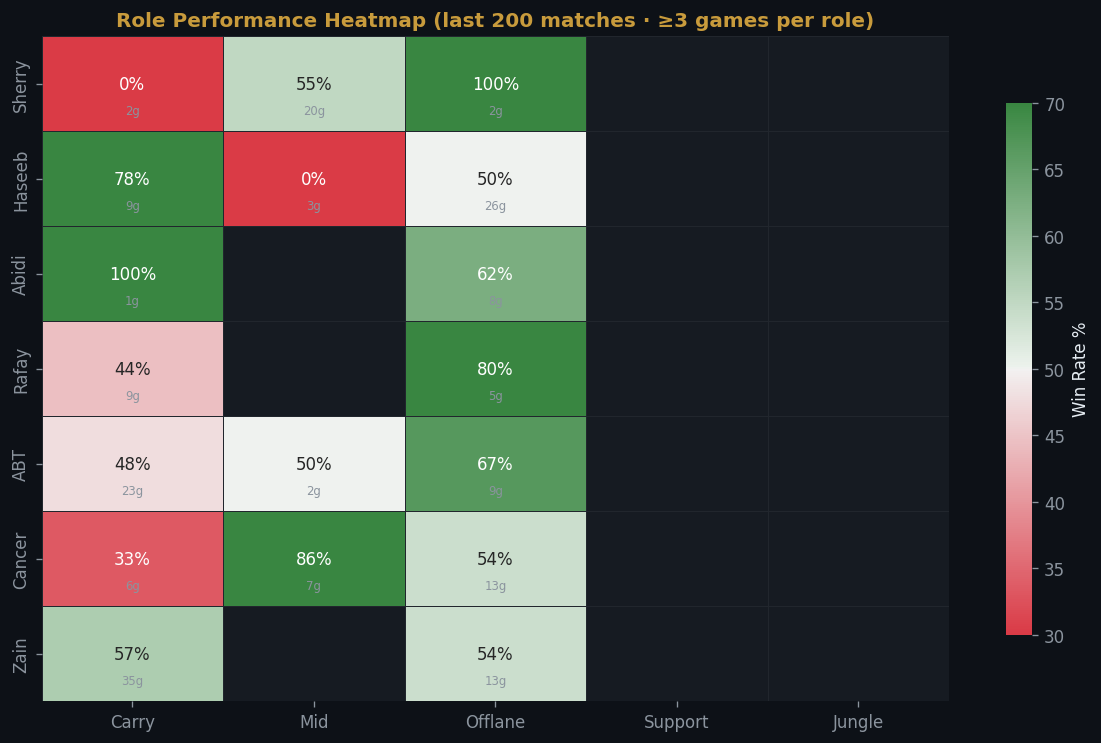


Duration Performance (200-match history):
Bucket  30-45min  <30min  >45min
Label                           
ABT         47.8    20.0    53.3
Abidi       49.5    58.3    49.4
Cancer      47.4    52.9    56.7
Haseeb      44.6    50.0    55.3
Rafay       51.3    50.0    44.9
Sherry      48.6    37.5    49.4
Zain        48.7    63.6    52.6


In [108]:
ROLE_ORDER = ['Carry', 'Mid', 'Offlane', 'Support', 'Jungle']

# Build role stats from 200-match DEEP cache (lane_role field)
role_data = {}
for aid, d in D.items():
    label   = d['label']
    buckets = {rn: {'games': 0, 'wins': 0} for rn in ROLE_NAMES.values()}
    for m in get_matches(aid):
        rn = ROLE_NAMES.get(m.get('lane_role'))
        if not rn:
            continue
        buckets[rn]['games'] += 1
        if m['won']:
            buckets[rn]['wins'] += 1
    role_data[label] = {
        rn: {'games': v['games'],
             'winrate': round(v['wins'] / v['games'] * 100, 1) if v['games'] else np.nan}
        for rn, v in buckets.items()
    }

# Heatmap: players × roles, colour = winrate
labels_p     = list(role_data.keys())
wr_matrix    = np.full((len(labels_p), len(ROLE_ORDER)), np.nan)
games_matrix = np.zeros((len(labels_p), len(ROLE_ORDER)), dtype=int)

for i, label in enumerate(labels_p):
    for j, role in enumerate(ROLE_ORDER):
        rd = role_data[label].get(role, {})
        wr_matrix[i, j]    = rd.get('winrate', np.nan)
        games_matrix[i, j] = rd.get('games', 0)

df_role_wr = pd.DataFrame(wr_matrix,    index=labels_p, columns=ROLE_ORDER)
annot_fn   = lambda v: f'{v:.0f}%' if not np.isnan(v) else '—'
annot_df   = df_role_wr.map(annot_fn)

fig, ax = plt.subplots(figsize=(10, max(4, len(labels_p) * 0.9)))
fig.patch.set_facecolor('#0d1117')
sns.heatmap(df_role_wr, ax=ax, cmap=sns.diverging_palette(10, 130, as_cmap=True),
            center=50, vmin=30, vmax=70,
            annot=annot_df, fmt='', linewidths=0.5, linecolor='#21262d',
            cbar_kws={'label': 'Win Rate %', 'shrink': 0.8})
ax.set_title(f'Role Performance Heatmap (last {MATCH_LIMIT} matches · ≥3 games per role)',
             color=GOLD, fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

# Overlay game counts
for i in range(len(labels_p)):
    for j in range(len(ROLE_ORDER)):
        g = games_matrix[i, j]
        if g > 0:
            ax.text(j + 0.5, i + 0.78, f'{g}g',
                    ha='center', va='center', fontsize=7, color='#8b949e')

plt.tight_layout()
plt.savefig('notebook_cache/t2_role_heatmap.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Duration buckets
dur_data = []
for aid, d in D.items():
    for bucket, lo, hi in [('<30min', 0, 1800), ('30-45min', 1800, 2700), ('>45min', 2700, 9999)]:
        ms = [m for m in get_matches(aid) if lo <= m.get('duration', 0) < hi]
        if not ms:
            continue
        wr = round(sum(1 for m in ms if m['won']) / len(ms) * 100, 1)
        dur_data.append({'Label': d['label'], 'Bucket': bucket, 'Games': len(ms), 'WR%': wr})

df_dur = pd.DataFrame(dur_data)
print(f'\nDuration Performance ({MATCH_LIMIT}-match history):')
print(df_dur.pivot_table(index='Label', columns='Bucket', values='WR%').to_string())

## 12 · Consistency Scores (KDA & GPM Variance)

Consistency (lower σ = more consistent) — 200-match history:
 Label  Avg KDA  KDA σ  Avg GPM  GPM σ  DMG/m σ   n
 Abidi     2.95   2.59    364.0   84.0    220.8 200
Haseeb     3.78   3.37    543.0  150.0    307.1 200
Cancer     3.86   4.27    493.0  171.0    332.8 200
  Zain     4.07   4.32    345.0   78.0    165.6 200
   ABT     4.21   4.37    478.0  163.0    288.8 200
 Rafay     4.63   5.39    563.0  130.0    368.9 200
Sherry     4.68   5.63    500.0  116.0    236.4 200


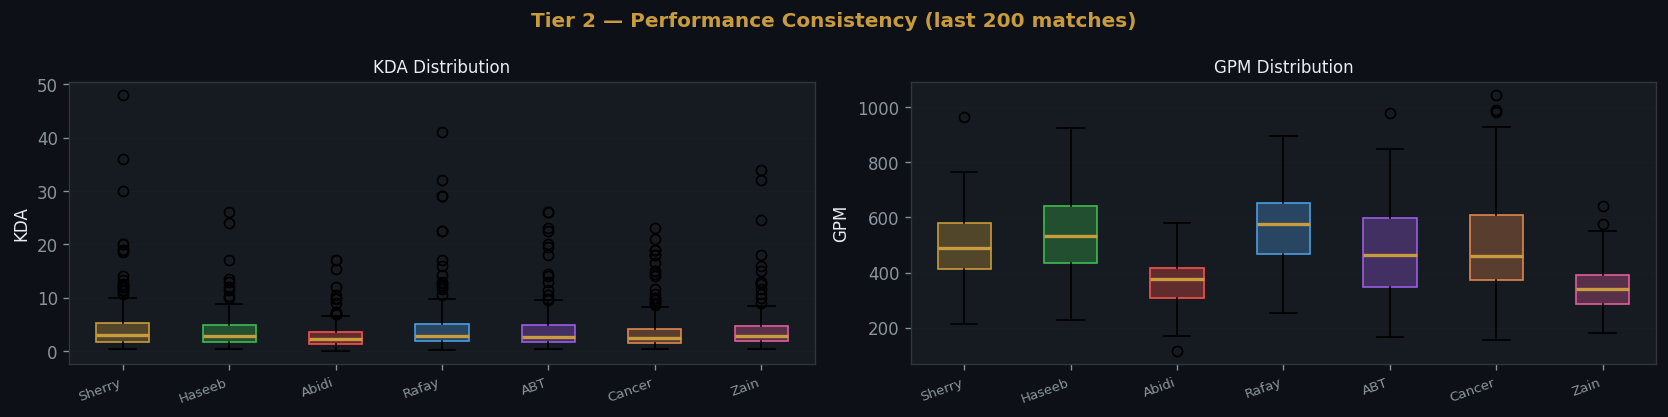

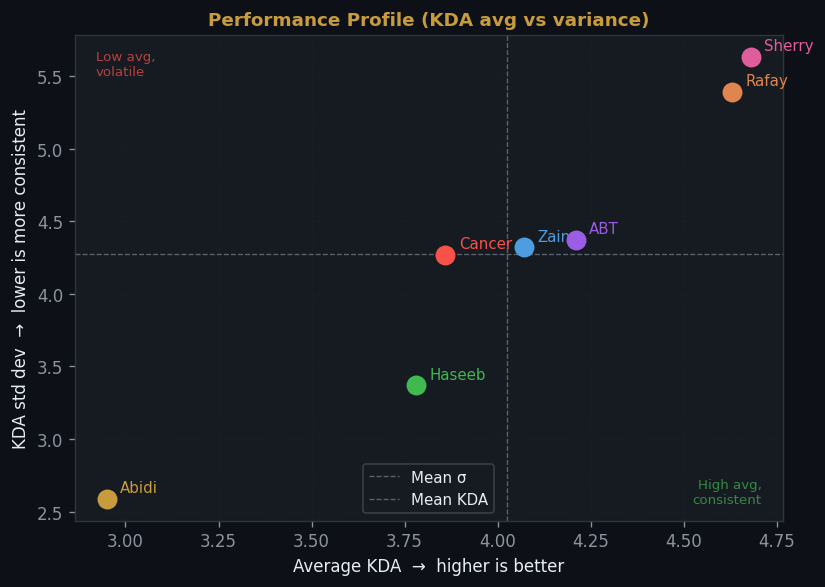

In [109]:
# Compute variance metrics for all players using full 200-match history
cons_rows = []
for aid, d in D.items():
    ms = get_matches(aid)
    if len(ms) < 2:
        continue
    kdas = [m['kda'] for m in ms]
    gpms = [m['gold_per_min'] for m in ms]
    dmgs = [m['dmg_per_min'] for m in ms]
    cons_rows.append({
        'Label':   d['label'],
        'Avg KDA': round(sum(kdas) / len(kdas), 2),
        'KDA σ':   round(statistics.stdev(kdas), 2),
        'Avg GPM': round(sum(gpms) / len(gpms), 0),
        'GPM σ':   round(statistics.stdev(gpms), 0),
        'DMG/m σ': round(statistics.stdev(dmgs), 1),
        'n':       len(ms),
    })

df_cons = pd.DataFrame(cons_rows).sort_values('KDA σ')
print(f'Consistency (lower σ = more consistent) — {MATCH_LIMIT}-match history:')
print(df_cons.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, max(3.5, len(FRIENDS) * 0.45)))
fig.suptitle(f'Tier 2 — Performance Consistency (last {MATCH_LIMIT} matches)',
             color=GOLD, fontsize=12, fontweight='bold')

# KDA box plots per player
ax = axes[0]
kda_by_player = [[m['kda'] for m in get_matches(f['account_id'])] for f in FRIENDS]
bp = ax.boxplot(kda_by_player, patch_artist=True, medianprops={'color': GOLD, 'linewidth': 2})
for patch, col in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(col + '55'); patch.set_edgecolor(col)
ax.set_xticklabels([f['label'] for f in FRIENDS], fontsize=8, rotation=20, ha='right')
ax.set_ylabel('KDA'); ax.set_title('KDA Distribution', fontsize=10); ax.grid(axis='y', alpha=0.3)

# GPM box plots per player
ax2 = axes[1]
gpm_by_player = [[m['gold_per_min'] for m in get_matches(f['account_id'])] for f in FRIENDS]
bp2 = ax2.boxplot(gpm_by_player, patch_artist=True, medianprops={'color': GOLD, 'linewidth': 2})
for patch, col in zip(bp2['boxes'], PALETTE):
    patch.set_facecolor(col + '55'); patch.set_edgecolor(col)
ax2.set_xticklabels([f['label'] for f in FRIENDS], fontsize=8, rotation=20, ha='right')
ax2.set_ylabel('GPM'); ax2.set_title('GPM Distribution', fontsize=10); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('notebook_cache/t2_consistency.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Scatter: Avg KDA vs KDA σ — the 'performance profile' view
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0d1117')
for i, row in df_cons.iterrows():
    col = PALETTE[list(df_cons.index).index(i) % len(PALETTE)]
    ax.scatter(row['Avg KDA'], row['KDA σ'], s=120, color=col, zorder=5)
    ax.annotate(row['Label'], (row['Avg KDA'], row['KDA σ']),
                textcoords='offset points', xytext=(8, 4), fontsize=9, color=col)

ax.axhline(df_cons['KDA σ'].mean(), color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6, label='Mean σ')
ax.axvline(df_cons['Avg KDA'].mean(), color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6, label='Mean KDA')
ax.set_xlabel('Average KDA  →  higher is better')
ax.set_ylabel('KDA std dev  →  lower is more consistent')
ax.set_title('Performance Profile (KDA avg vs variance)', color=GOLD, fontsize=11, fontweight='bold')
ax.legend(framealpha=0.2, fontsize=9); ax.grid(alpha=0.3)
ax.text(0.97, 0.03, 'High avg,\nconsistent', transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color=GREEN, alpha=0.7)
ax.text(0.03, 0.97, 'Low avg,\nvolatile',    transform=ax.transAxes, ha='left',  va='top',    fontsize=8, color=RED,   alpha=0.7)
plt.tight_layout()
plt.savefig('notebook_cache/t2_performance_profile.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 13 · Differential Analysis — Marginal Win-Rate

Measures how each player's win-rate shifts relative to **their own career baseline** across three dimensions:
1. **With teammate** — Δ WR when queueing with a specific friend (≥5 games together, from `/peers`)
2. **By role** — Δ WR per lane role (200-match DEEP cache, ≥3 games in role)
3. **By hero** — Δ WR on each hero vs baseline (career stats, ≥5 games on hero)

Results are saved to `data/diff_player_x_*.parquet`.
> Requires §2b to be run first for full 200-match role data.

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

def _save_parquet(df: pd.DataFrame, path: str) -> None:
    """Write a DataFrame to parquet using pyarrow directly, bypassing pandas'
    PyArrowImpl wrapper which calls patch_pyarrow() and raises ArrowKeyError
    in some pandas/pyarrow version combinations."""
    pq.write_table(pa.Table.from_pandas(df, preserve_index=False), path)

# ── Baselines & lookup tables ─────────────────────────────────────────────────
baselines = {}
for aid, d in D.items():
    w, l = d['wl']['win'], d['wl']['lose']
    baselines[aid] = w / (w + l) * 100 if (w + l) else 50.0

label_map  = {aid: d['label'] for aid, d in D.items()}
all_labels = [label_map[aid] for aid in [f['account_id'] for f in FRIENDS] if aid in label_map]
Path('data').mkdir(exist_ok=True)

# ── 1 · Player × Player ───────────────────────────────────────────────────────
pp_rows = []
for i_aid, d in D.items():
    peer_map = {p['account_id']: p for p in d['peers']}
    base = baselines[i_aid]
    for j_aid in D:
        if i_aid == j_aid:
            continue
        p = peer_map.get(j_aid)
        if p and p.get('with_games', 0) >= 5:
            with_wr = p['with_win'] / p['with_games'] * 100
            pp_rows.append({
                'player':      label_map[i_aid],
                'with_player': label_map[j_aid],
                'baseline_wr': round(base, 2),
                'with_wr':     round(with_wr, 2),
                'delta':       round(with_wr - base, 2),
                'games':       p['with_games'],
            })

df_pp = pd.DataFrame(pp_rows)
_save_parquet(df_pp, 'data/diff_player_x_player.parquet')

# ── 2 · Player × Role ─────────────────────────────────────────────────────────
# Uses get_matches() — 200-match DEEP cache when §2b has been run.
_ROLE_NAMES = {1: 'Carry', 2: 'Mid', 3: 'Offlane', 4: 'Jungle', 5: 'Support'}
_ROLE_ORDER = ['Carry', 'Mid', 'Offlane', 'Support', 'Jungle']
n_matches   = max(len(get_matches(aid)) for aid in D)

role_rows = []
for aid, d in D.items():
    base    = baselines[aid]
    label   = label_map[aid]
    buckets = {rn: {'g': 0, 'w': 0} for rn in _ROLE_NAMES.values()}
    for m in get_matches(aid):
        rn = _ROLE_NAMES.get(m.get('lane_role'))
        if rn:
            buckets[rn]['g'] += 1
            if m['won']:
                buckets[rn]['w'] += 1
    for role, v in buckets.items():
        if v['g'] >= 3:
            role_wr = v['w'] / v['g'] * 100
            role_rows.append({
                'player':      label,
                'role':        role,
                'baseline_wr': round(base, 2),
                'role_wr':     round(role_wr, 2),
                'delta':       round(role_wr - base, 2),
                'games':       v['g'],
            })

df_pr = pd.DataFrame(role_rows)
_save_parquet(df_pr, 'data/diff_player_x_role.parquet')

# ── 3 · Player × Hero ─────────────────────────────────────────────────────────
# Parquet stores >=5 games (used by the probability model).
# The plot below filters to >=50 games for statistical reliability.
hero_rows = []
for aid, d in D.items():
    base  = baselines[aid]
    label = label_map[aid]
    for h in d['heroes']:
        if h['games'] < 5:
            continue
        hero_wr = h['win'] / h['games'] * 100
        hero_rows.append({
            'player':      label,
            'hero_id':     h['hero_id'],
            'hero':        HERO_NAMES.get(h['hero_id'], f'Hero {h["hero_id"]}'),
            'baseline_wr': round(base, 2),
            'hero_wr':     round(hero_wr, 2),
            'delta':       round(hero_wr - base, 2),
            'games':       h['games'],
        })

df_ph = pd.DataFrame(hero_rows)
_save_parquet(df_ph, 'data/diff_player_x_hero.parquet')

print(f'Using {n_matches}-match history (DEEP cache)')
print('Saved to data/:')
print(f'  diff_player_x_player.parquet  — {len(df_pp)} pairs (>=5 games together)')
print(f'  diff_player_x_role.parquet    — {len(df_pr)} entries (>=3 games in role)')
print(f'  diff_player_x_hero.parquet    — {len(df_ph)} hero entries (>=5 career games, model threshold)')
print('\nBaseline win-rates:')
for aid in [f['account_id'] for f in FRIENDS]:
    if aid in baselines:
        print(f'  {label_map[aid]:8s}  {baselines[aid]:.1f}%')

DIV_CMAP = sns.diverging_palette(10, 130, as_cmap=True)

# ── Figure 1 · Player × Player heatmap ────────────────────────────────────────
if df_pp.empty:
    print('\n[Player×Player] No pairs with >=5 games — re-run §2 after adding new friends.')
else:
    pp_pivot = df_pp.pivot_table(index='player', columns='with_player', values='delta')
    pp_pivot = pp_pivot.reindex(all_labels, axis=0).reindex(all_labels, axis=1)
    annot_pp = pp_pivot.map(lambda v: f'{v:+.1f}' if pd.notna(v) else '·')

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0d1117')
    sns.heatmap(pp_pivot, ax=ax, cmap=DIV_CMAP, center=0, vmin=-20, vmax=20,
                annot=annot_pp, fmt='', linewidths=0.5, linecolor='#21262d',
                cbar_kws={'label': 'Delta Win Rate %', 'shrink': 0.7},
                annot_kws={'size': 11, 'fontweight': 'bold'})
    ax.set_title(
        'Player x Player — Delta WR vs career baseline when playing together\n'
        "(row-player's WR lift when queueing with column-player · >=5 games)",
        color=GOLD, fontsize=11, fontweight='bold')
    ax.set_xlabel('Playing with -->', fontsize=9)
    ax.set_ylabel('Player -->', fontsize=9)
    plt.tight_layout()
    plt.savefig('notebook_cache/diff_player_x_player.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()

# ── Figure 2 · Player × Role heatmap ──────────────────────────────────────────
if df_pr.empty:
    print('\n[Player×Role] No role data — run §2b first (>=3 games per role required).')
else:
    pr_pivot = df_pr.pivot_table(index='player', columns='role', values='delta')
    pr_pivot = pr_pivot.reindex(all_labels, axis=0).reindex(_ROLE_ORDER, axis=1)
    gm_pivot = df_pr.pivot_table(index='player', columns='role', values='games', aggfunc='sum')
    gm_pivot = gm_pivot.reindex(all_labels, axis=0).reindex(_ROLE_ORDER, axis=1)
    annot_pr = pr_pivot.map(lambda v: f'{v:+.0f}%' if pd.notna(v) else '—')

    fig, ax = plt.subplots(figsize=(9, max(4, len(all_labels) * 0.85)))
    fig.patch.set_facecolor('#0d1117')
    sns.heatmap(pr_pivot, ax=ax, cmap=DIV_CMAP, center=0, vmin=-35, vmax=35,
                annot=annot_pr, fmt='', linewidths=0.5, linecolor='#21262d',
                cbar_kws={'label': 'Delta Win Rate %', 'shrink': 0.7},
                annot_kws={'size': 10, 'fontweight': 'bold'})
    for i, player in enumerate(pr_pivot.index):
        for j, role in enumerate(pr_pivot.columns):
            try:
                g = gm_pivot.loc[player, role]
                if pd.notna(g) and int(g) > 0:
                    ax.text(j + 0.5, i + 0.82, f'{int(g)}g',
                            ha='center', va='center', fontsize=7, color='#8b949e')
            except KeyError:
                pass
    ax.set_title(
        f'Player x Role — Delta WR vs career baseline  ({n_matches}-match cache · >=3 games per role)',
        color=GOLD, fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('notebook_cache/diff_player_x_role.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()

# ── Figure 3 · Hero lift — top 5 heroes per player (>=50 games only) ──────────
if df_ph.empty:
    print('\n[Player×Hero] No hero data available.')
else:
    ncols     = 4
    nrows     = (len(all_labels) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.2, nrows * 3.8))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        'Hero Lift — Delta WR vs career baseline  (>=50 games on hero · top 5 shown)',
        color=GOLD, fontsize=12, fontweight='bold')
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx, player in enumerate(all_labels):
        ax   = axes_flat[idx]
        col  = PALETTE[idx % len(PALETTE)]
        aid  = next((a for a, d in D.items() if d['label'] == player), None)
        base = baselines.get(aid, 50.0)
        # Plot filter: >=50 games for statistical reliability.
        # Parquet file retains >=5 games for the probability model.
        sub  = df_ph[(df_ph['player'] == player) & (df_ph['games'] >= 50)]

        if sub.empty:
            ax.text(0.5, 0.5, 'No heroes\nwith >=50 games', ha='center', va='center',
                    transform=ax.transAxes, color='#8b949e', fontsize=9)
            ax.set_title(f'{player}  (base {base:.0f}%)', fontsize=10, color=col)
            ax.axis('off')
            continue

        sub = sub.sort_values('delta', ascending=True).tail(5)
        bar_colors = [GREEN if v >= 0 else RED for v in sub['delta']]
        bars = ax.barh(sub['hero'], sub['delta'], color=bar_colors,
                       edgecolor='#21262d', height=0.6, alpha=0.85)
        ax.axvline(0, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.set_facecolor('#161b22')

        for bar, val, g in zip(bars, sub['delta'], sub['games']):
            xpos = bar.get_width() + (0.5 if val >= 0 else -0.5)
            ha   = 'left' if val >= 0 else 'right'
            ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                    f'{val:+.1f}%  {int(g)}g', va='center', fontsize=7.5, ha=ha, color='#e6edf3')

        ax.set_title(f'{player}  (base {base:.0f}%)', fontsize=10, color=col)
        ax.set_xlabel('Delta WR %', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(axis='x', alpha=0.3)

    for idx in range(len(all_labels), len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.tight_layout()
    plt.savefig('notebook_cache/diff_hero_lift.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()

## 14 · Weight Calibration (logistic regression on DEEP cache)

Fits the seven additive signal weights **w\_A4, w\_A2, w\_A3, w\_A5, w\_B, w\_C, w\_D** and the sigmoid temperature **T** using all DEEP-cache matches that contain at least one tracked player.

Optimisation:
- Negative log-likelihood + L2 penalty toward default weights (train split)
- Temperature T calibrated separately by minimising Brier score on validation split

Requires §§2b and 13 to have been run (parquet files + match cache must exist).

In [ ]:
import sys, json, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit

sys.path.insert(0, str(pathlib.Path('.').resolve()))
warnings.filterwarnings('ignore')

from app.probability import (
    WinProbabilityModel, DEFAULT_WEIGHTS,
    K_HERO, K_ROLE, K_HERO_ROLE, K_SYNERGY,
    _ROLE_PAIR_WEIGHT, ROLE_ID_TO_NAME,
)

DATA_DIR  = pathlib.Path('data')
CACHE_DIR = DATA_DIR / 'match_cache' / 'matches'

model      = WinProbabilityModel.load()
FRIEND_IDS = set(model.labels.keys())
print("Tracked:", list(model.labels.values()))

# ── Raw (pre-weight) signal extraction ───────────────────────────────────────

def _player_raw(p):
    aid, hero_id = p.get('account_id'), p.get('hero_id')
    role_id      = p.get('lane_role') or 1
    is_friend    = aid in FRIEND_IDS
    baseline     = model.baselines.get(aid, 50.0) if is_friend else 50.0

    # A2 hero fit
    he  = model.hero_deltas.get(aid, {}).get(hero_id) if is_friend else None
    a2  = model._shrink(he['delta'], he['n'], K_HERO) if he else 0.0

    # A3 role fit
    rn  = ROLE_ID_TO_NAME.get(role_id, 'Carry')
    re_ = model.role_deltas.get(aid, {}).get(rn) if is_friend else None
    a3  = model._shrink(re_['delta'], re_['n'], K_ROLE) if re_ else 0.0

    # A4 hero×role (replaces A2+A3 when n>=3)
    a4, using_a4 = 0.0, False
    if is_friend:
        hr = model.hero_role_stats.get(aid, {}).get(role_id, {}).get(hero_id)
        if hr and hr['n'] >= 3:
            a4, using_a4 = model._shrink(hr['wr'] - baseline, hr['n'], K_HERO_ROLE), True

    form = model.form_deltas.get(aid, 0.0) if is_friend else 0.0
    return baseline, (a4 if using_a4 else 0.0), (0.0 if using_a4 else a2), (0.0 if using_a4 else a3), form


def _synergy_raw(team):
    ids = [p['account_id'] for p in team if p.get('account_id') in FRIEND_IDS]
    tot = 0.0
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            a, b  = ids[i], ids[j]
            avail = [d for d in (model.teammate_deltas.get(a, {}).get(b),
                                  model.teammate_deltas.get(b, {}).get(a)) if d]
            if not avail:
                continue
            raw = sum(d['delta'] for d in avail) / len(avail)
            n   = min(d['n'] for d in avail)
            if n >= 5:
                tot += model._shrink(raw, n, K_SYNERGY)
    return tot


def _matchup_raw(rad, dire):
    ws = cs = 0.0
    for rp in rad:
        for dp in dire:
            h_r, h_d = rp.get('hero_id'), dp.get('hero_id')
            rr, dr   = rp.get('lane_role') or 1, dp.get('lane_role') or 1
            if not h_r or not h_d:
                continue
            edge = model.matchup_matrix.get(h_r, {}).get(h_d)
            if edge is None:
                continue
            rw = _ROLE_PAIR_WEIGHT.get((rr, dr), 0.0)
            if rw:
                cs += edge * rw; ws += rw
    return cs / ws if ws else 0.0


def _meta_raw(team):
    return sum(
        model.global_meta.get(p.get('hero_id'), {}).get(p.get('lane_role') or 1, 0.0)
        for p in team if p.get('hero_id')
    )


def _extract(match):
    players = match.get('players', [])
    rad     = [p for p in players if p.get('isRadiant')]
    dire    = [p for p in players if not p.get('isRadiant')]
    tracked = {p.get('account_id') for p in players if p.get('account_id') in FRIEND_IDS}
    if not tracked:
        return None

    rs = [_player_raw(p) for p in rad]
    ds = [_player_raw(p) for p in dire]

    def diff(idx): return sum(s[idx] for s in rs) - sum(s[idx] for s in ds)
    return {
        'radiant_win':   int(match.get('radiant_win', False)),
        'start_time':    match.get('start_time', 0),
        'baseline_diff': diff(0),
        'a4_diff':       diff(1),
        'a2_diff':       diff(2),
        'a3_diff':       diff(3),
        'a5_diff':       diff(4),
        'b_diff':        _synergy_raw(rad) - _synergy_raw(dire),
        'c_raw':         _matchup_raw(rad, dire),
        'd_diff':        _meta_raw(rad) - _meta_raw(dire),
        'n_tracked':     len(tracked),
    }

# ── Load matches ─────────────────────────────────────────────────────────────

rows, n_total = [], 0
for f in sorted(CACHE_DIR.glob('*.json')):
    try:
        m = json.loads(f.read_text())
        n_total += 1
        row = _extract(m)
        if row is not None:
            rows.append(row)
    except Exception:
        pass

df = pd.DataFrame(rows).sort_values('start_time').reset_index(drop=True)
print(f"\nMatches with tracked players: {len(df)} / {n_total}  |  Radiant WR: {df['radiant_win'].mean():.1%}")

# ── Train / test split (80 / 20 chronological) ───────────────────────────────

FEAT_COLS   = ['a4_diff', 'a2_diff', 'a3_diff', 'a5_diff', 'b_diff', 'c_raw', 'd_diff']
WEIGHT_KEYS = ['w_A4', 'w_A2', 'w_A3', 'w_A5', 'w_B', 'w_C', 'w_D']
DEFAULTS    = np.array([DEFAULT_WEIGHTS[k] for k in WEIGHT_KEYS])
T_DEFAULT   = DEFAULT_WEIGHTS['T']

split  = int(len(df) * 0.8)
train  = df.iloc[:split].reset_index(drop=True)
test   = df.iloc[split:].reset_index(drop=True)

Xtr, Xte = train[FEAT_COLS].values, test[FEAT_COLS].values
ytr, yte  = train['radiant_win'].values, test['radiant_win'].values
Btr, Bte  = train['baseline_diff'].values, test['baseline_diff'].values

print(f"Train: {len(train)} matches  |  Test: {len(test)} matches")

# ── Step 1: fit weights via NLL + L2 (T fixed at default) ────────────────────

L2_LAMBDA = 0.05   # L2 strength -- keeps weights near defaults given limited data

def nll_l2(w):
    score = Btr + Xtr @ w
    prob  = np.clip(expit(score / T_DEFAULT), 1e-9, 1 - 1e-9)
    nll   = -np.mean(ytr * np.log(prob) + (1 - ytr) * np.log(1 - prob))
    l2    = L2_LAMBDA * np.sum((w - DEFAULTS) ** 2)
    return nll + l2

res = minimize(nll_l2, DEFAULTS, method='L-BFGS-B',
               bounds=[(0.0, 4.0)] * len(DEFAULTS),
               options={'maxiter': 2000, 'ftol': 1e-12})
opt_w = res.x
print(f"\nOptimisation converged: {res.success}  ({res.message})")

# ── Step 2: calibrate T on validation set (Brier score) ──────────────────────

def brier(T):
    score = Bte + Xte @ opt_w
    prob  = expit(score / T)
    return float(np.mean((prob - yte) ** 2))

T_res = minimize(brier, T_DEFAULT, method='Nelder-Mead',
                 bounds=[(2.0, 80.0)],
                 options={'xatol': 0.05, 'fatol': 1e-6, 'maxiter': 500})
opt_T = float(T_res.x[0])
print(f"Optimal T: {opt_T:.2f}  (default: {T_DEFAULT:.1f})")

# ── Evaluation ────────────────────────────────────────────────────────────────

def evaluate(X, B, y, w, T, label=''):
    score = B + X @ w
    prob  = np.clip(expit(score / T), 1e-9, 1 - 1e-9)
    bs    = float(np.mean((prob - y) ** 2))
    ll    = float(-np.mean(y * np.log(prob) + (1 - y) * np.log(1 - prob)))
    acc   = float(np.mean((prob > 0.5) == y))
    naive = float(np.mean((0.5 - y) ** 2))
    print(f"{label:25s}  log-loss={ll:.4f}  Brier={bs:.4f} (naive={naive:.4f})  acc={acc:.1%}")
    return expit((B + X @ w) / T)

print()
p_def_te  = evaluate(Xte, Bte, yte, DEFAULTS, T_DEFAULT, "Defaults (test)")
p_cal_te  = evaluate(Xte, Bte, yte, opt_w,    opt_T,     "Calibrated (test)")
p_cal_tr  = evaluate(Xtr, Btr, ytr, opt_w,    opt_T,     "Calibrated (train)")

# ── Plots ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
DARK, LIGHT, ACCENT = '#0d1117', '#aaaaaa', '#00d4ff'

# -- Calibration curve (decile buckets)
ax = axes[0]
ax.set_facecolor(DARK)
n_bins = 10
edges  = np.linspace(0, 1, n_bins + 1)
bx, by, bsz = [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    mask = (p_cal_te >= lo) & (p_cal_te < hi)
    if mask.sum() >= 3:
        bx.append(float(p_cal_te[mask].mean()))
        by.append(float(yte[mask].mean()))
        bsz.append(int(mask.sum()))

ax.plot([0, 1], [0, 1], '--', color='#555', lw=1, label='Perfect')
sc = ax.scatter(bx, by, s=[sz * 8 for sz in bsz], c=ACCENT, zorder=3, label='Calibrated', alpha=0.9)
ax.set_xlabel('Predicted probability', color=LIGHT)
ax.set_ylabel('Actual radiant WR',      color=LIGHT)
ax.set_title('Calibration curve (test set)', color='white', fontsize=11)
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.tick_params(colors=LIGHT)
for sp in ax.spines.values():
    sp.set_color('#333')

# -- Weight comparison bar chart
ax2 = axes[1]
ax2.set_facecolor(DARK)
x    = np.arange(len(WEIGHT_KEYS))
w    = 0.38
ax2.bar(x - w/2, DEFAULTS, w, label='Default',     color='#555',  alpha=0.85)
ax2.bar(x + w/2, opt_w,    w, label='Calibrated',  color=ACCENT,  alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(WEIGHT_KEYS, rotation=30, ha='right', color=LIGHT, fontsize=9)
ax2.set_ylabel('Weight value', color=LIGHT)
ax2.set_title(f'Signal weights  (T: {T_DEFAULT:.1f} → {opt_T:.2f})', color='white', fontsize=11)
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax2.tick_params(colors=LIGHT)
for sp in ax2.spines.values():
    sp.set_color('#333')

plt.tight_layout()
plt.show()

# ── Save weights ─────────────────────────────────────────────────────────────

calibrated = {k: round(float(v), 4) for k, v in zip(WEIGHT_KEYS, opt_w)}
calibrated['T'] = round(opt_T, 4)

out = DATA_DIR / 'model_weights.json'
out.write_text(json.dumps(calibrated, indent=2), encoding='utf-8')
print(f"\nSaved {out}")
print(json.dumps(calibrated, indent=2))